# Code

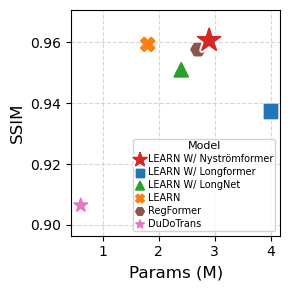

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patheffects as pe
# Dữ liệu mô phỏng
models = [
    'LEARN W/ Nyströmformer', 
    'LEARN W/ Longformer', 
    'LEARN W/ LongNet', 
    'LEARN W/ Mamba', 
    'LEARN', 
    'RegFormer', 
    'DuDoTrans'
]
ssim_values = [0.960681676864624, 0.937358260154724, 0.951, 0.584675788879394, 0.959364354610443, 0.957664012908935, 0.9064]
params = [2.9, 4.0, 2.4, 2.9, 1.8, 2.7, 0.6]

# Tạo đồ thị
fig, ax = plt.subplots(figsize=(3, 3))

# Marker cho các mô hình
shapes = ['P', 's', '^', 'D', 'X', 'H', '*']

# Bảng màu (tách biệt cao)
palette = {
    'LEARN W/ Nyströmformer': '#d62728',  # vivid red
    'LEARN W/ Longformer'   : '#1f77b4',  # blue
    'LEARN W/ LongNet'      : '#2ca02c',  # green
    'LEARN W/ Mamba'        : '#9467bd',  # purple
    'LEARN'                 : '#ff7f0e',  # orange
    'RegFormer'             : '#8c564b',  # brown
    'DuDoTrans'             : '#e377c2',  # pink
}

# Vẽ với lọc SSIM > 0.85 và không viền đen
for i, model in enumerate(models):
    if ssim_values[i] <= 0.85:
        continue  # loại Mamba
    c = palette[model]
    if model == 'LEARN W/ Nyströmformer':
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=300, color=c, marker='*', zorder=6, label=model, clip_on=False
        )
        # Halo trắng dày để nổi bật (thay cho viền đen)
        pts.set_path_effects([
            pe.withStroke(linewidth=4.0, foreground='white'),
            pe.Normal()
        ])
    else:
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=100, color=c, marker=shapes[i], zorder=3, label=model, clip_on=False
        )
        # Halo trắng mỏng giúp tách nền và vẫn không có viền đen
        pts.set_path_effects([
            pe.withStroke(linewidth=2.0, foreground='white'),
            pe.Normal()
        ])

ax.set_xlabel('Params (M)', fontsize=12)
ax.set_ylabel('SSIM', fontsize=12)

# Set ticks đúng như yêu cầu
ax.set_yticks([0.90, 0.92, 0.94, 0.96, 0.98])

# Legend: ký hiệu nhỏ lại, không ảnh hưởng kích thước điểm thật
ax.legend(
    title='Model',
    fontsize=7, title_fontsize=8,
    loc='lower right',
    frameon=True, framealpha=0.85,
    borderpad=0.2, handlelength=1.0,
    handletextpad=0.3, labelspacing=0.3,
    markerscale=0.6,    # << thu nhỏ marker trong legend
    scatterpoints=1
)

# Giới hạn trục tập trung vùng SSIM cao
yvals = [v for v in ssim_values if v > 0.85]
ax.set_ylim(min(yvals) - 0.01, max(yvals) + 0.01)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./Visualization/trade_off.png', bbox_inches='tight', dpi=300)


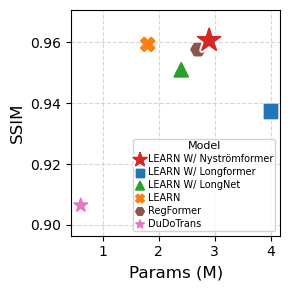

In [8]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

# ==== PDF chất lượng cao ====
mpl.rcParams['pdf.fonttype'] = 42          # embed TrueType để text sắc nét & copy được
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['pdf.use14corefonts'] = False
mpl.rcParams['pdf.compression'] = 0        # không nén (file lớn hơn nhưng an toàn chất lượng)

# ==== Dữ liệu ====
models = [
    'LEARN W/ Nyströmformer',
    'LEARN W/ Longformer',
    'LEARN W/ LongNet',
    'LEARN W/ Mamba',
    'LEARN',
    'RegFormer',
    'DuDoTrans'
]
ssim_values = [0.960681676864624, 0.937358260154724, 0.951, 0.584675788879394, 0.959364354610443, 0.957664012908935, 0.9064]
params = [2.9, 4.0, 2.4, 2.9, 1.8, 2.7, 0.6]

# ==== Cấu hình figure ====
fig, ax = plt.subplots(figsize=(3, 3))

shapes = ['P', 's', '^', 'D', 'X', 'H', '*']  # marker cho từng model

# Bảng màu tách biệt (Tableau 10)
palette = {
    'LEARN W/ Nyströmformer': '#d62728',  # vivid red (nhấn mạnh)
    'LEARN W/ Longformer'   : '#1f77b4',  # blue
    'LEARN W/ LongNet'      : '#2ca02c',  # green
    'LEARN W/ Mamba'        : '#9467bd',  # purple
    'LEARN'                 : '#ff7f0e',  # orange
    'RegFormer'             : '#8c564b',  # brown
    'DuDoTrans'             : '#e377c2',  # pink
}

# ==== Vẽ (lọc SSIM > 0.85, bỏ viền đen; legend marker nhỏ, scatter vẫn to) ====
for i, model in enumerate(models):
    if ssim_values[i] <= 0.85:
        continue  # loại điểm SSIM thấp (ví dụ Mamba)
    c = palette[model]
    if model == 'LEARN W/ Nyströmformer':
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=300, color=c, marker='*',
            zorder=6, label=model, clip_on=False
        )
        # Halo trắng dày để nổi bật thay cho viền đen
        pts.set_path_effects([
            pe.withStroke(linewidth=4.0, foreground='white'),
            pe.Normal()
        ])
    else:
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=100, color=c, marker=shapes[i],
            zorder=3, label=model, clip_on=False
        )
        # Halo trắng mỏng để tách nền
        pts.set_path_effects([
            pe.withStroke(linewidth=2.0, foreground='white'),
            pe.Normal()
        ])

# ==== Nhãn, legend, trục ====
ax.set_xlabel('Params (M)', fontsize=12)
ax.set_ylabel('SSIM', fontsize=12)
# Set ticks đúng như yêu cầu
ax.set_yticks([0.90, 0.92, 0.94, 0.96, 0.98])
ax.legend(
    title='Model',
    fontsize=7, title_fontsize=8,
    loc='lower right',
    frameon=True, framealpha=0.85,
    borderpad=0.2, handlelength=1.0,
    handletextpad=0.3, labelspacing=0.3,
    markerscale=0.6,     # ký hiệu trong legend nhỏ lại
    scatterpoints=1
)

# Giới hạn y để tập trung vùng SSIM cao
yvals = [v for v in ssim_values if v > 0.85]
ax.set_ylim(min(yvals) - 0.01, max(yvals) + 0.01)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

# ==== Lưu PDF (dpi cao cho phần raster như halo) ====
plt.savefig(
    './Visualization/trade_off.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=1200,           # cao cho các hiệu ứng raster (halo)
    transparent=False
)


# Code dl

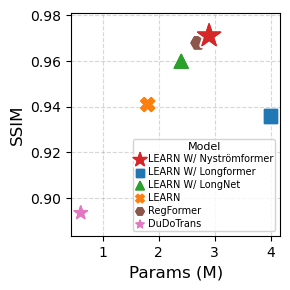

In [4]:
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

models = [
    'LEARN W/ Nyströmformer',
    'LEARN W/ Longformer',
    'LEARN W/ LongNet',
    'LEARN W/ Mamba',
    'LEARN',
    'RegFormer',
    'DuDoTrans'
]
ssim_values = [0.971053063869476, 0.935769975185394, 0.959901, 0.546445965766906, 0.940964937210083, 0.967962026596069, 0.8935]
params = [2.9, 4.0, 2.4, 2.9, 1.8, 2.7, 0.6]

fig, ax = plt.subplots(figsize=(3, 3))

# Marker cho các mô hình
shapes = ['P', 's', '^', 'D', 'X', 'H', '*']

# Bảng màu (tách biệt cao)
palette = {
    'LEARN W/ Nyströmformer': '#d62728',  # vivid red
    'LEARN W/ Longformer'   : '#1f77b4',  # blue
    'LEARN W/ LongNet'      : '#2ca02c',  # green
    'LEARN W/ Mamba'        : '#9467bd',  # purple
    'LEARN'                 : '#ff7f0e',  # orange
    'RegFormer'             : '#8c564b',  # brown
    'DuDoTrans'             : '#e377c2',  # pink
}

# Vẽ với lọc SSIM > 0.85 và không viền đen
for i, model in enumerate(models):
    if ssim_values[i] <= 0.85:
        continue  # loại Mamba
    c = palette[model]
    if model == 'LEARN W/ Nyströmformer':
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=300, color=c, marker='*', zorder=6, label=model, clip_on=False
        )
        # Halo trắng dày để nổi bật (thay cho viền đen)
        pts.set_path_effects([
            pe.withStroke(linewidth=4.0, foreground='white'),
            pe.Normal()
        ])
    else:
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=100, color=c, marker=shapes[i], zorder=3, label=model, clip_on=False
        )
        # Halo trắng mỏng giúp tách nền và vẫn không có viền đen
        pts.set_path_effects([
            pe.withStroke(linewidth=2.0, foreground='white'),
            pe.Normal()
        ])

ax.set_xlabel('Params (M)', fontsize=12)
ax.set_ylabel('SSIM', fontsize=12)

# Legend: ký hiệu nhỏ lại, không ảnh hưởng kích thước điểm thật
ax.legend(
    title='Model',
    fontsize=7, title_fontsize=8,
    loc='lower right',
    frameon=True, framealpha=0.85,
    borderpad=0.2, handlelength=1.0,
    handletextpad=0.3, labelspacing=0.3,
    markerscale=0.6,    # << thu nhỏ marker trong legend
    scatterpoints=1
)

# Giới hạn trục tập trung vùng SSIM cao
yvals = [v for v in ssim_values if v > 0.85]
ax.set_ylim(min(yvals) - 0.01, max(yvals) + 0.01)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('./Visualization/trade_off_dl.png', bbox_inches='tight', dpi=300)

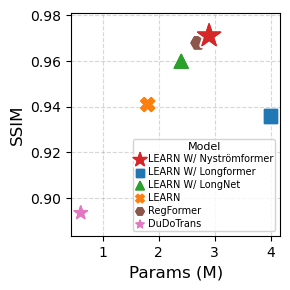

In [9]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patheffects as pe

# ==== PDF chất lượng cao ====
mpl.rcParams['pdf.fonttype'] = 42          # embed TrueType để text sắc nét & copy được
mpl.rcParams['ps.fonttype']  = 42
mpl.rcParams['pdf.use14corefonts'] = False
mpl.rcParams['pdf.compression'] = 0        # không nén (file lớn hơn nhưng an toàn chất lượng)

# ==== Dữ liệu ====
models = [
    'LEARN W/ Nyströmformer',
    'LEARN W/ Longformer',
    'LEARN W/ LongNet',
    'LEARN W/ Mamba',
    'LEARN',
    'RegFormer',
    'DuDoTrans'
]
ssim_values = [0.971053063869476, 0.935769975185394, 0.959901, 0.546445965766906, 0.940964937210083, 0.967962026596069, 0.8935]
params      = [2.9,                    4.0,                    2.4,       2.9,                      1.8,                    2.7,                      0.6]

# ==== Cấu hình figure ====
fig, ax = plt.subplots(figsize=(3, 3))

shapes = ['P', 's', '^', 'D', 'X', 'H', '*']  # marker cho từng model

# Bảng màu tách biệt (Tableau 10)
palette = {
    'LEARN W/ Nyströmformer': '#d62728',  # vivid red (nhấn mạnh)
    'LEARN W/ Longformer'   : '#1f77b4',  # blue
    'LEARN W/ LongNet'      : '#2ca02c',  # green
    'LEARN W/ Mamba'        : '#9467bd',  # purple
    'LEARN'                 : '#ff7f0e',  # orange
    'RegFormer'             : '#8c564b',  # brown
    'DuDoTrans'             : '#e377c2',  # pink
}

# ==== Vẽ (lọc SSIM > 0.85, bỏ viền đen; legend marker nhỏ, scatter vẫn to) ====
for i, model in enumerate(models):
    if ssim_values[i] <= 0.85:
        continue  # loại điểm SSIM thấp (ví dụ Mamba)
    c = palette[model]
    if model == 'LEARN W/ Nyströmformer':
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=300, color=c, marker='*',
            zorder=6, label=model, clip_on=False
        )
        # Halo trắng dày để nổi bật thay cho viền đen
        pts.set_path_effects([
            pe.withStroke(linewidth=4.0, foreground='white'),
            pe.Normal()
        ])
    else:
        pts = ax.scatter(
            params[i], ssim_values[i],
            s=100, color=c, marker=shapes[i],
            zorder=3, label=model, clip_on=False
        )
        # Halo trắng mỏng để tách nền
        pts.set_path_effects([
            pe.withStroke(linewidth=2.0, foreground='white'),
            pe.Normal()
        ])

# ==== Nhãn, legend, trục ====
ax.set_xlabel('Params (M)', fontsize=12)
ax.set_ylabel('SSIM', fontsize=12)
ax.set_yticks([0.90, 0.92, 0.94, 0.96, 0.98])
ax.legend(
    title='Model',
    fontsize=7, title_fontsize=8,
    loc='lower right',
    frameon=True, framealpha=0.85,
    borderpad=0.2, handlelength=1.0,
    handletextpad=0.3, labelspacing=0.3,
    markerscale=0.6,     # ký hiệu trong legend nhỏ lại
    scatterpoints=1
)

# Giới hạn y để tập trung vùng SSIM cao
yvals = [v for v in ssim_values if v > 0.85]
ax.set_ylim(min(yvals) - 0.01, max(yvals) + 0.01)
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()

# ==== Lưu PDF (dpi cao cho phần raster như halo) ====
plt.savefig(
    './Visualization/trade_off_dl.pdf',
    format='pdf',
    bbox_inches='tight',
    dpi=1200,           # cao cho các hiệu ứng raster (halo)
    transparent=False
)